# Prédiction du temps de livraison — Food Delivery

**Objectif métier** : prédire `delivery_time_min` (temps de livraison, en minutes) à partir des caractéristiques de la commande, du livreur, du trafic et de la météo.

**Dataset** : `food-delivery.csv` — 45593 lignes, 20 colonnes brutes.

## Sommaire
1. Chargement et nettoyage
2. Exploration (EDA)
3. Transformation et modélisation
4. Optimisation et évaluation

## 1. Chargement et nettoyage

### 1.1 Import des librairies et chargement des données

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/food-delivery.csv")
# df.columns.tolist()
df.shape

(45593, 20)

### 1.2 Suppression des colonnes sans valeur prédictive

- `ID` : identifiant unique de la commande, aucune valeur prédictive.
- `Delivery_person_ID` : identifiant du livreur (1320 valeurs uniques).

In [2]:
df = df.drop(columns=['ID', 'Delivery_person_ID'])
df.shape

(45593, 18)

### 1.3 Renommage des colonnes

In [3]:
df = df.rename(columns={
    'Delivery_person_Age': 'delivery_person_age',
    'Delivery_person_Ratings': 'delivery_person_ratings',
    'Restaurant_latitude': 'restaurant_lat',
    'Restaurant_longitude': 'restaurant_lon',
    'Delivery_location_latitude': 'delivery_lat',
    'Delivery_location_longitude': 'delivery_lon',
    'Order_Date': 'order_date',
    'Time_Orderd': 'time_ordered',
    'Time_Order_picked': 'time_picked',
    'Weatherconditions': 'weather',
    'Road_traffic_density': 'traffic',
    'Vehicle_condition': 'vehicle_condition',
    'Type_of_order': 'order_type',
    'Type_of_vehicle': 'vehicle_type',
    'Festival': 'festival',
    'City': 'city',
    'Time_taken(min)': 'delivery_time_min',
})

df.columns.tolist()

['delivery_person_age',
 'delivery_person_ratings',
 'restaurant_lat',
 'restaurant_lon',
 'delivery_lat',
 'delivery_lon',
 'order_date',
 'time_ordered',
 'time_picked',
 'weather',
 'traffic',
 'vehicle_condition',
 'order_type',
 'vehicle_type',
 'multiple_deliveries',
 'festival',
 'city',
 'delivery_time_min']

### 1.4 Nettoyage des espaces parasites


In [4]:
columns_str = df.select_dtypes(include='str').columns
# print(columns_str)

for col in columns_str:
    df[col] = df[col].str.strip()

# for col in columns_str:
#     print(df[col].unique())
#     print('----------------')
df['traffic'].unique()

<StringArray>
['High', 'Jam', 'Low', 'Medium', 'NaN']
Length: 5, dtype: str

### 1.5 Conversion des colonnes numériques

`delivery_person_age`, `delivery_person_ratings`, `multiple_deliveries` sont en texte. Aucune valeur mal formée détectée (vérifié : pas de virgule décimale). `pd.to_numeric(errors='coerce')` convertit directement les chaînes numériques et transforme `"NaN"` en `np.nan` au passage.

In [5]:
# for col in ['delivery_person_age', 'delivery_person_ratings', 'multiple_deliveries']:
#     suspects = df[col][df[col].astype(str).str.contains(',')]
#     print(col, ':', suspects.unique())
numeric_cols = ['delivery_person_age', 'delivery_person_ratings', 'multiple_deliveries']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# print(df.info())
df[numeric_cols].isna().sum()



delivery_person_age        1854
delivery_person_ratings    1908
multiple_deliveries         993
dtype: int64

### 1.6 Traitement de la valeur aberrante dans `delivery_person_ratings`


In [6]:
df.loc[df['delivery_person_ratings'] == 6, 'delivery_person_ratings'] = np.nan
print((df['delivery_person_ratings'] == 6).sum())
print(df['delivery_person_ratings'].isna().sum())
print(df['delivery_person_ratings'].max())



0
1961
5.0


### 1.7 Correction des coordonnées GPS négatives


In [7]:
# df.columns.tolist()
df['restaurant_lat'] = df['restaurant_lat'].abs()
df['restaurant_lon'] = df['restaurant_lon'].abs()
print((df['restaurant_lat'] < 0).sum())
print((df['restaurant_lon'] < 0).sum())


0
0


### 1.8 Traitement des coordonnées placeholder


In [8]:
df.loc[(df['restaurant_lat'] == 0) & (df['restaurant_lon'] == 0), ['restaurant_lat', 'restaurant_lon']] = np.nan
df.loc[(df['delivery_lat'] == 0.01) & (df['delivery_lon'] == 0.01), ['delivery_lat', 'delivery_lon']] = np.nan

print("Restaurant coords manquantes :", df['restaurant_lat'].isna().sum())
print("Delivery coords manquantes :", df['delivery_lat'].isna().sum())



Restaurant coords manquantes : 3640
Delivery coords manquantes : 327


### 1.9 Extraction de la cible et nettoyage de la météo


In [9]:
df['delivery_time_min'] = df['delivery_time_min'].str.extract(r'(\d+)').astype(int)
df['weather'] = df['weather'].str.replace('conditions ', '', regex=False)
# df['delivery_time_min'].head()
df['weather'].unique()
print(df['weather'].isna().sum())


0


### 1.9 Correction du "NaN" textuel restant dans `weather`


In [10]:
df['weather'] = df['weather'].replace('NaN', np.nan, regex=False)
df['weather'].isna().sum()

np.int64(616)

### 1.10 Conversion des dates et heures


In [11]:
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y', errors='coerce')

time_ordered = pd.to_datetime(df['time_ordered'], format='%H:%M:%S', errors='coerce')
time_picked = pd.to_datetime(df['time_picked'], format='%H:%M:%S', errors='coerce')

mask_minuit = time_picked < time_ordered
time_picked = time_picked.where(~mask_minuit, time_picked + pd.Timedelta(days=1))

df['time_ordered'] = time_ordered
df['time_picked'] = time_picked

print(df[['order_date', 'time_ordered', 'time_picked']].dtypes)
print((df['time_picked'] < df['time_ordered']).sum())

order_date      datetime64[us]
time_ordered    datetime64[us]
time_picked     datetime64[us]
dtype: object
0


### 1.12 Imputation des valeurs manquantes

Conformément à la consigne du brief, l'imputation est effectuée directement à cette étape, sur l'ensemble du dataset :
- **Variables numériques** (`delivery_person_age`, `delivery_person_ratings`) : imputation par la **médiane**, robuste aux valeurs extrêmes.
- **Variables catégorielles à faible cardinalité et déséquilibrées** (`multiple_deliveries`, `festival`) : imputation par le **mode** (valeur la plus fréquente).

Les colonnes `traffic`, `city`, ainsi que les coordonnées GPS et `time_ordered`, sont traitées séparément à l'étape d'exploration (EDA), où l'analyse des fréquences et corrélations permettra un choix plus informé.

In [12]:
# Médiane pour les numériques
for col in ['delivery_person_age', 'delivery_person_ratings']:
    median = df[col].median()
    df[col] = df[col].fillna(median)

    # Mode pour les catégorielles simples
df['festival'] = df['festival'].replace('NaN', np.nan, regex=False)
print(df['festival'].unique())

for col in ['multiple_deliveries', 'festival']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

print(df.isna().sum())

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
delivery_person_age           0
delivery_person_ratings       0
restaurant_lat             3640
restaurant_lon             3640
delivery_lat                327
delivery_lon                327
order_date                    0
time_ordered               1731
time_picked                   0
weather                     616
traffic                       0
vehicle_condition             0
order_type                    0
vehicle_type                  0
multiple_deliveries           0
festival                      0
city                          0
delivery_time_min             0
dtype: int64


### 1.13 Correction du "NaN" textuel dans `traffic` et `city`


In [13]:
df['traffic'] = df['traffic'].replace('NaN', np.nan)
df['city'] = df['city'].replace('NaN', np.nan)

print(df[['traffic', 'city']].isna().sum())

traffic     601
city       1200
dtype: int64


### 1.14 Imputation de `weather`, `traffic`, création de `preparation_time`, imputation de `city`


In [14]:
df['weather'] = df['weather'].fillna('Missing')
df['traffic'] = df['traffic'].fillna('Missing')

city_mode = df['city'].mode()[0]
df['city'] = df['city'].fillna(city_mode)
print("city imputé avec le mode :", city_mode)


df['preparation_time'] = (df['time_picked'] - df['time_ordered']).dt.total_seconds() / 60
print(df[['preparation_time', 'city', 'traffic', 'weather']].isna().sum())

city imputé avec le mode : Metropolitian
preparation_time    1731
city                   0
traffic                0
weather                0
dtype: int64


## 2. Exploration et analyse des dépendances (EDA)

### 2.1 Statistiques descriptives globales

Vue d'ensemble des variables numériques (moyenne, médiane, écart-type) et catégorielles (fréquences), avant toute analyse de relation avec la cible.

In [15]:
df.describe()


,delivery_person_age,delivery_person_ratings,restaurant_lat,restaurant_lon,delivery_lat,delivery_lon,order_date,time_ordered,time_picked,vehicle_condition,multiple_deliveries,delivery_time_min,preparation_time
count,45593.000000,45593.000000,41953.000000,41953.000000,45266.000000,45266.000000,45593,43862,45593,45593.000000,45593.000000,45593.000000,43862.000000
mean,29.584739,4.635040,18.911397,76.923408,17.591282,71.357417,2022-03-13 16:32:53.987235,1900-01-01 17:54:59.856368,1900-01-01 18:03:32.157568,1.023359,0.750225,26.294607,9.989399
min,15.000000,1.000000,9.957144,72.768726,0.020000,0.020000,2022-02-11 00:00:00,1900-01-01 00:00:00,1900-01-01 00:00:00,0.000000,0.000000,10.000000,5.000000
25%,25.000000,4.600000,12.986047,73.898520,12.994264,73.773613,2022-03-04 00:00:00,1900-01-01 15:25:00,1900-01-01 15:30:00,0.000000,0.000000,19.000000,5.000000
50%,30.000000,4.700000,19.065838,76.618203,18.643935,76.014212,2022-03-15 00:00:00,1900-01-01 19:15:00,1900-01-01 19:25:00,1.000000,1.000000,26.000000,10.000000
75%,34.000000,4.800000,22.751234,78.368855,22.788060,78.117151,2022-03-27 00:00:00,1900-01-01 21:35:00,1900-01-01 21:45:00,2.000000,1.000000,32.000000,15.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-04-06 00:00:00,1900-01-01 23:55:00,1900-01-02 00:10:00,3.000000,3.000000,54.000000,15.000000
std,5.696333,0.324598,5.467829,3.502910,7.209419,20.315410,NaN,NaN,NaN,0.839065,0.567430,9.383806,4.087516


In [16]:
categorical_cols = df.select_dtypes(include='str').columns
# print(categorical_cols.tolist())

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).round(3) * 100)
    print()






--- weather ---
weather
Fog           16.8
Stormy        16.6
Cloudy        16.5
Sandstorms    16.4
Windy         16.3
Sunny         16.0
Missing        1.4
Name: proportion, dtype: float64

--- traffic ---
traffic
Low        33.9
Jam        31.0
Medium     24.0
High        9.7
Missing     1.3
Name: proportion, dtype: float64

--- order_type ---
order_type
Snack     25.3
Meal      25.1
Drinks    24.8
Buffet    24.7
Name: proportion, dtype: float64

--- vehicle_type ---
vehicle_type
motorcycle          58.0
scooter             33.5
electric_scooter     8.4
bicycle              0.1
Name: proportion, dtype: float64

--- festival ---
festival
No     98.0
Yes     2.0
Name: proportion, dtype: float64

--- city ---
city
Metropolitian    77.4
Urban            22.2
Semi-Urban        0.4
Name: proportion, dtype: float64



### 2.2 Distribution de la variable cible (`delivery_time_min`)

Analyse de la forme de la distribution : symétrie, présence de valeurs extrêmes

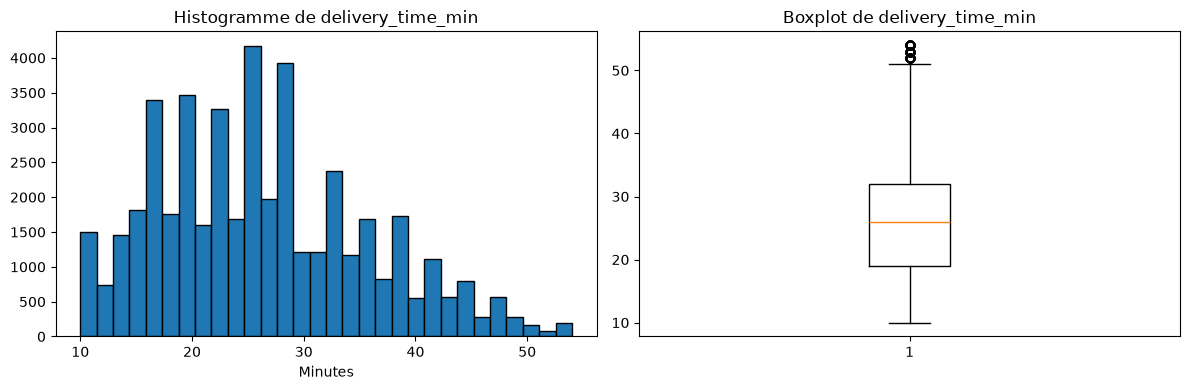

Asymétrie (skewness) : 0.4859512298743323
count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: delivery_time_min, dtype: float64


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['delivery_time_min'], bins=30, edgecolor='black')
axes[0].set_title('Histogramme de delivery_time_min')
axes[0].set_xlabel('Minutes')

axes[1].boxplot(df['delivery_time_min'])
axes[1].set_title('Boxplot de delivery_time_min')

plt.tight_layout()
plt.show()

print("Asymétrie (skewness) :", df['delivery_time_min'].skew())
print(df['delivery_time_min'].describe())

**Observations** :
- Distribution légèrement asymétrique positivement (skewness = 0,49), asymétrie faible, aucune transformation nécessaire.
- Moyenne (26,29) et médiane (26,00) très proches, confirmant une distribution raisonnablement équilibrée.
- Quelques valeurs au-delà de ~52 minutes visibles sur le boxplot, cohérentes avec le maximum observé (54 min)

### 2.3 Feature engineering

On crée deux nouvelles features, comme demandé par le brief :
1. **`distance_km`** : distance entre le restaurant et le point de livraison, calculée avec la formule de Haversine 
2. **`preparation_time`** : déjà créée à l'étape 1, ses valeurs manquantes sont imputées ici par la médiane.

In [18]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # rayon de la Terre en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(df['restaurant_lat'], df['restaurant_lon'], df['delivery_lat'], df['delivery_lon'])

print(df['distance_km'].describe())

median_disntance = df['distance_km'].median()
df['distance_km'] = df['distance_km'].fillna(median_disntance)

median_prep_time = df['preparation_time'].median()
df['preparation_time'] = df['preparation_time'].fillna(median_prep_time)
print(df[['distance_km', 'preparation_time']].isna().sum())



count    41953.000000
mean         9.720284
std          5.603083
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: distance_km, dtype: float64
distance_km         0
preparation_time    0
dtype: int64


### 2.4 Relation entre la cible et les variables numériques


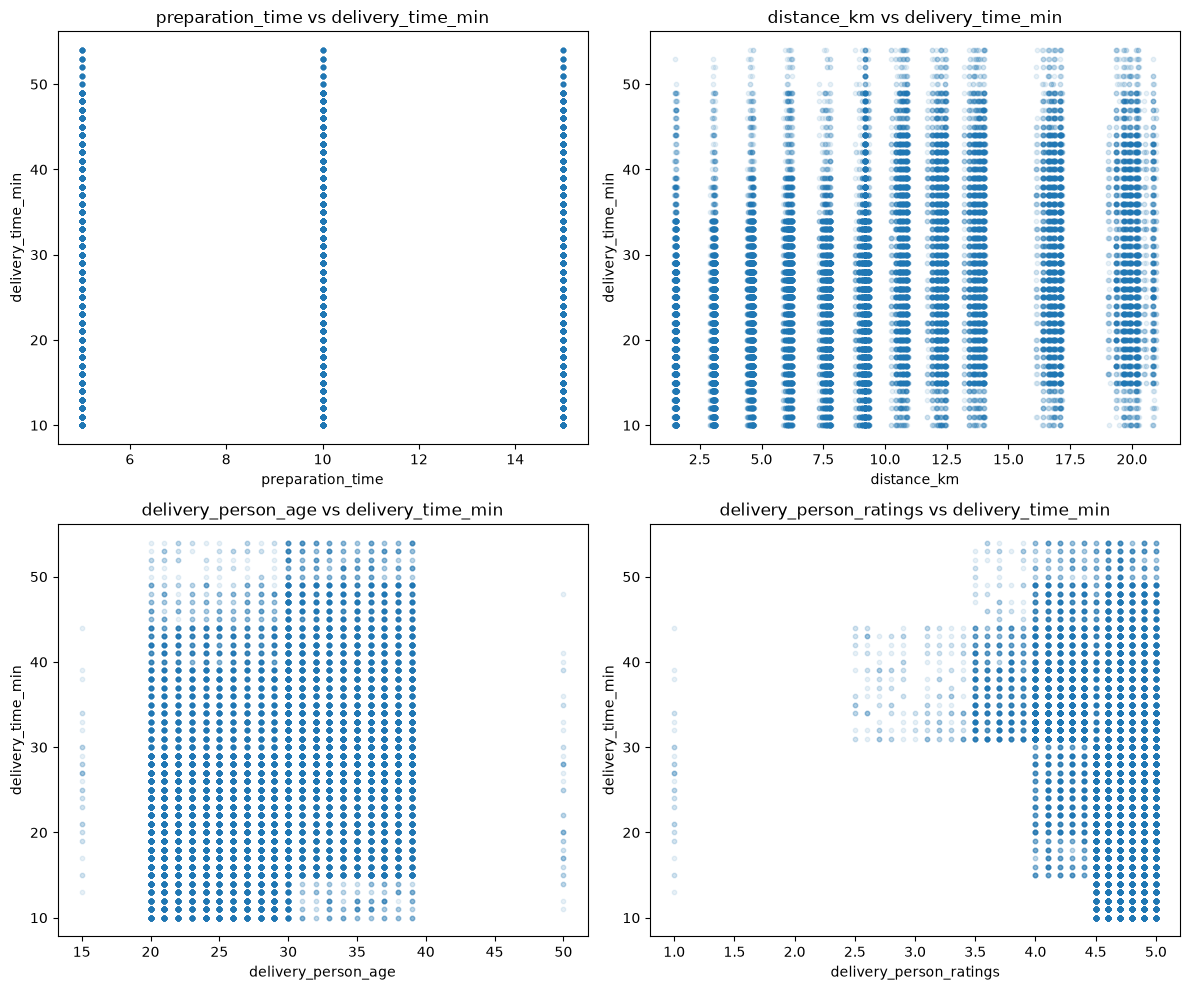

Correlation preparation_time / delivery_time_min: -0.01
Correlation distance_km / delivery_time_min: 0.31
Correlation delivery_person_age / delivery_time_min: 0.29
Correlation delivery_person_ratings / delivery_time_min: -0.33


In [19]:
numerics_vals = ['preparation_time', 'distance_km', 'delivery_person_age', 'delivery_person_ratings']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numerics_vals):
    axes[i].scatter(df[col], df['delivery_time_min'], alpha=0.1, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('delivery_time_min')
    axes[i].set_title(f'{col} vs delivery_time_min')

plt.tight_layout()
plt.show()

for col in numerics_vals:
    corr = df[col].corr(df['delivery_time_min'])
    print(f"Correlation {col} / delivery_time_min: {corr:.2f}")

### 2.5 Remplacement de `preparation_time` par des features temporelles

- **`order_hour`** : heure de la commande (0-23), pour capter d'éventuels effets d'heures de pointe.
- **`is_weekend`** : commande passée un samedi/dimanche ou non.
Les manquants de `time_ordered` (~1731) sont imputés par le **mode**

In [20]:
df = df.drop(columns=['preparation_time'])
order_hour_mode = df['time_ordered'].dt.hour.mode()[0]
df['order_hour'] = df['time_ordered'].dt.hour.fillna(order_hour_mode)
# print(order_hour_mode)
# print(df['order_hour'].isna().sum())
# print(df['order_hour'].dtype)
df['order_hour'] = df['order_hour'].astype(int)

df['is_weekend'] = df['order_date'].dt.day_of_week.isin([5, 6])
print(df['order_hour'].dtype)
print(df['order_hour'].describe())
print(df['is_weekend'].value_counts())

int64
count    45593.000000
mean        17.559735
std          4.774677
min          0.000000
25%         15.000000
50%         19.000000
75%         21.000000
max         23.000000
Name: order_hour, dtype: float64
is_weekend
False    33054
True     12539
Name: count, dtype: int64


In [21]:
numeric_vars = ['distance_km', 'order_hour', 'delivery_person_age', 'delivery_person_ratings']

for col in numeric_vars:
    corr = df[col].corr(df['delivery_time_min'])
    print(f"Corrélation {col} / delivery_time_min : {corr:.3f}")

Corrélation distance_km / delivery_time_min : 0.307
Corrélation order_hour / delivery_time_min : 0.179
Corrélation delivery_person_age / delivery_time_min : 0.293
Corrélation delivery_person_ratings / delivery_time_min : -0.333


**Synthèse des corrélations numériques avec la cible** :

| Variable | Corrélation |
|---|---|
| delivery_person_ratings | -0.333 |
| distance_km | 0.307 |
| delivery_person_age | 0.293 |
| order_hour | 0.179 |

### 2.6 Relation entre la cible et les variables catégorielles

Boxplots de `delivery_time_min` par catégorie, pour chaque variable catégorielle.

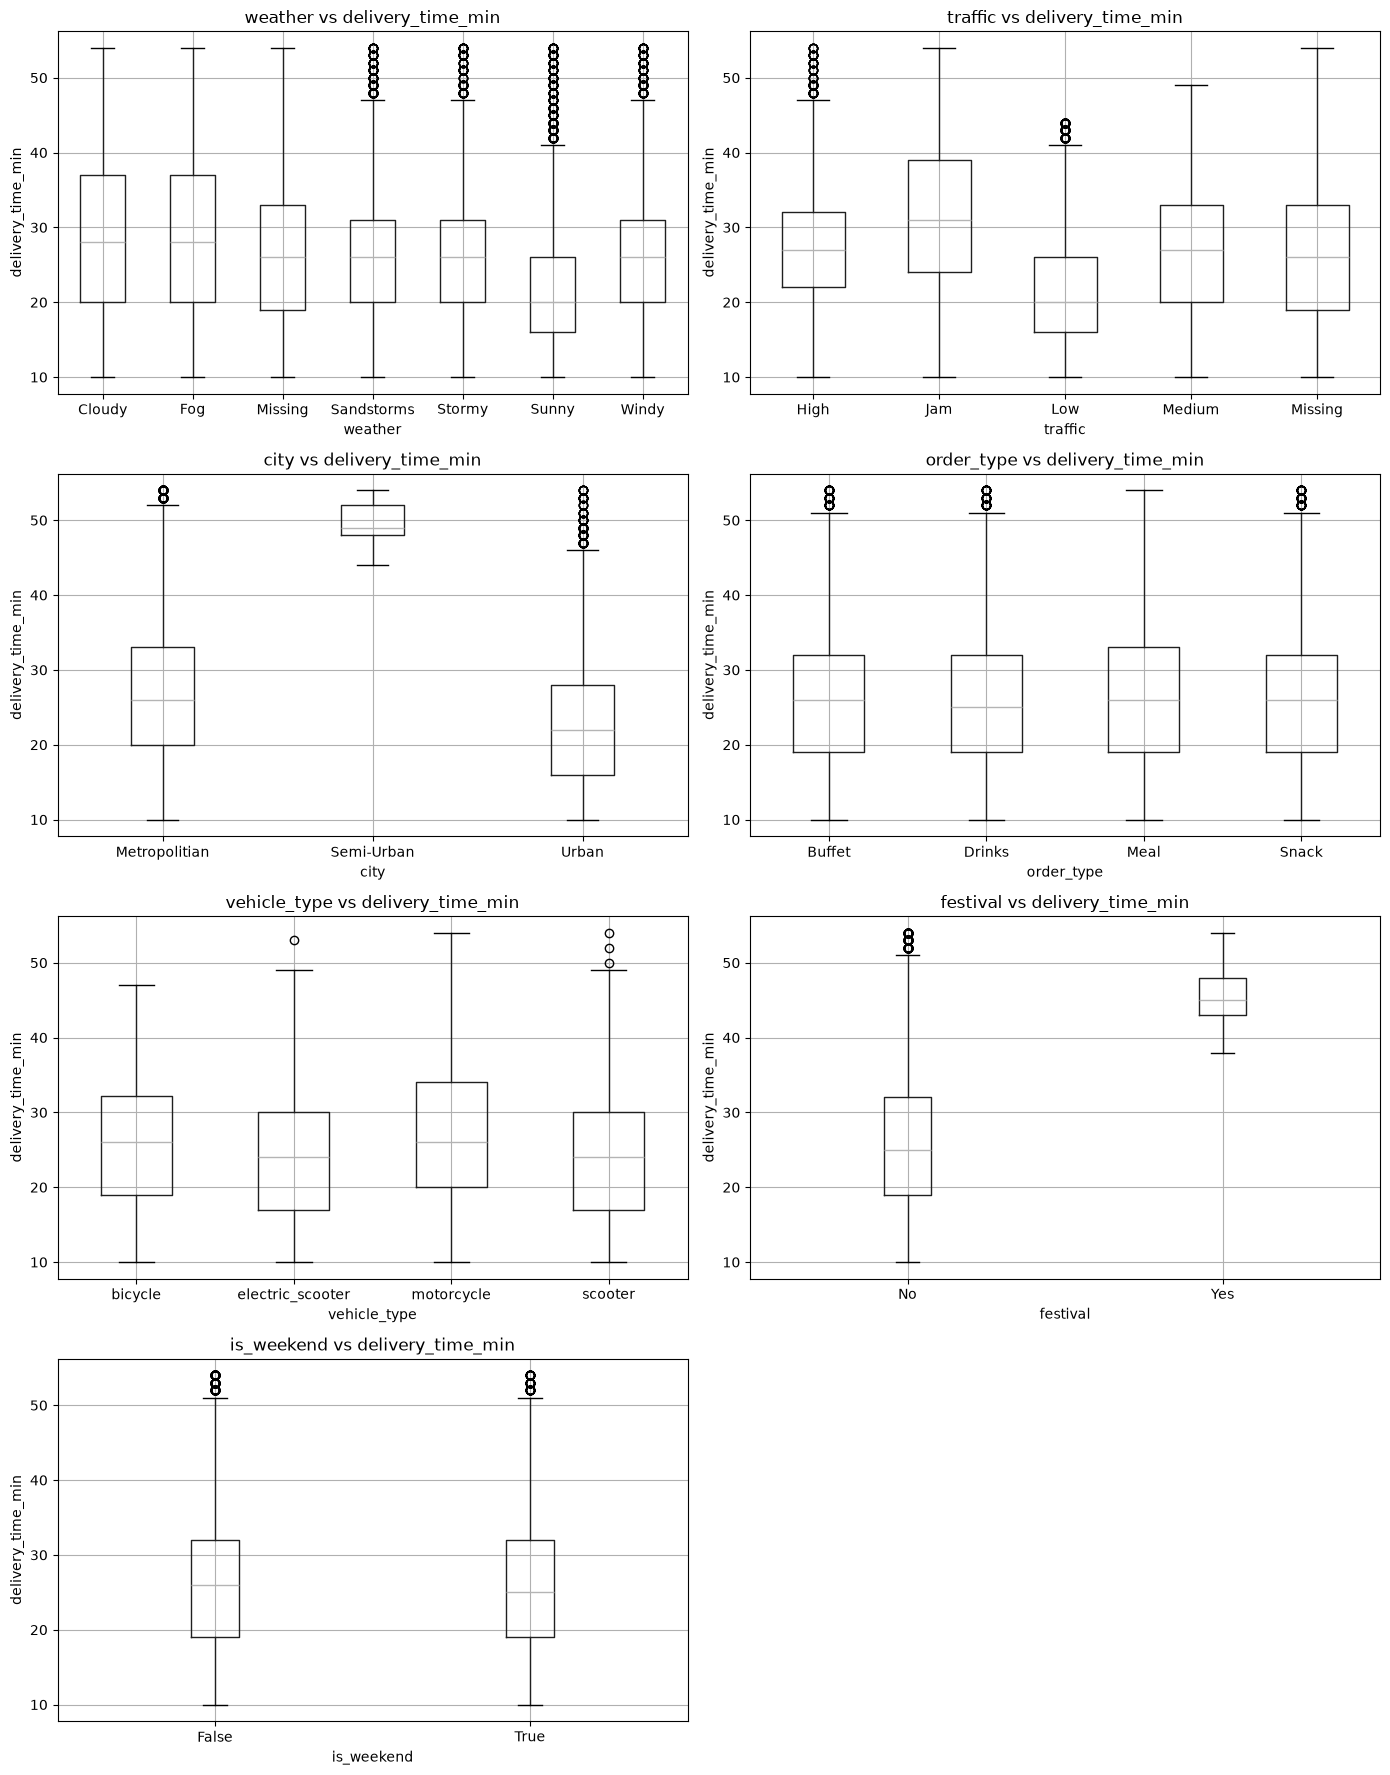

In [22]:
categorical_vars = ['weather', 'traffic', 'city', 'order_type', 'vehicle_type', 'festival', 'is_weekend']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    df.boxplot(column='delivery_time_min', by=col, ax=axes[i])
    axes[i].set_title(f'{col} vs delivery_time_min')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('delivery_time_min')

# Cacher le dernier subplot vide (7 variables pour 8 emplacements)
axes[-1].axis('off')

plt.suptitle('')  # retire le titre auto ajouté par pandas
plt.tight_layout()
plt.show()

In [23]:
print(df.groupby('city')['distance_km'].mean())
print(df.groupby('city')['traffic'].value_counts(normalize=True))
print()
print(df.groupby('festival')['distance_km'].mean())
print(df.groupby('festival')['traffic'].value_counts(normalize=True))

city
Metropolitian     9.835935
Semi-Urban       12.534046
Urban             9.082718
Name: distance_km, dtype: float64
city           traffic
Metropolitian  Low        0.322557
               Jam        0.322472
               Medium     0.243108
               High       0.098121
               Missing    0.013742
Semi-Urban     Jam        0.823171
               High       0.103659
               Medium     0.067073
               Missing    0.006098
Urban          Low        0.403808
               Jam        0.259175
               Medium     0.232439
               High       0.093232
               Missing    0.011346
Name: proportion, dtype: float64

festival
No      9.613477
Yes    12.906324
Name: distance_km, dtype: float64
festival  traffic
No        Low        0.345146
          Jam        0.302325
          Medium     0.242007
          High       0.097456
          Missing    0.013066
Yes       Jam        0.703125
          Medium     0.145089
          High       0.07700

### 2.7 Matrice de corrélation


                         delivery_person_age  delivery_person_ratings  \
delivery_person_age                 1.000000                -0.084623   
delivery_person_ratings            -0.084623                 1.000000   
distance_km                        -0.001284                -0.097819   
order_hour                          0.003054                -0.059090   
vehicle_condition                   0.004788                 0.026800   
multiple_deliveries                 0.111274                -0.112589   
delivery_time_min                   0.292861                -0.332933   

                         distance_km  order_hour  vehicle_condition  \
delivery_person_age        -0.001284    0.003054           0.004788   
delivery_person_ratings    -0.097819   -0.059090           0.026800   
distance_km                 1.000000    0.537138           0.008583   
order_hour                  0.537138    1.000000           0.021778   
vehicle_condition           0.008583    0.021778           1

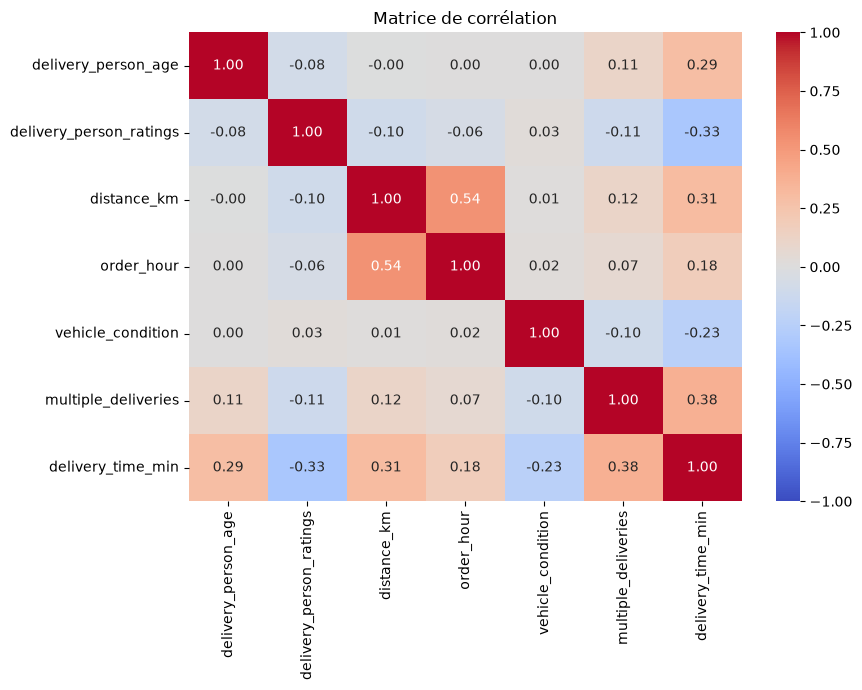

delivery_time_min          1.000000
multiple_deliveries        0.378276
distance_km                0.307431
delivery_person_age        0.292861
order_hour                 0.178849
vehicle_condition         -0.234398
delivery_person_ratings   -0.332933
Name: delivery_time_min, dtype: float64


In [24]:
import seaborn as sns

numerics_corr = ['delivery_person_age', 'delivery_person_ratings', 'distance_km', 'order_hour', 'vehicle_condition', 'multiple_deliveries', 'delivery_time_min']

corr_matric = df[numerics_corr].corr()
print(corr_matric)
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matric, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

print(corr_matric['delivery_time_min'].sort_values(ascending=False))

### 2.8 Synthèse de l'EDA

**Variables numériques les plus liées à la cible** (par corrélation) :
| Variable | Corrélation |
|---|---|
| multiple_deliveries | 0.378 |
| delivery_person_ratings | -0.333 |
| distance_km | 0.307 |
| delivery_person_age | 0.293 |
| vehicle_condition | -0.234 |
| order_hour | 0.179 |

**Variables catégorielles les plus discriminantes** : `traffic` et `weather`, avec un effet cohérent avec l'intuition métier. `city` et `festival` montrent un effet apparent fort, mais partiellement confondu avec `traffic` et `distance_km`.

Aucune variable seule n'explique fortement la cible (toutes < 0.4 en valeur absolue), ce qui suggère un phénomène multifactoriel — argument en faveur de modèles capables de capter des interactions entre variables (Random Forest, Gradient Boosting) plutôt qu'une régression linéaire simple.

Corrélation notable entre deux variables explicatives : `distance_km` et `order_hour` (0.54), modérée, à surveiller en cas d'usage d'un modèle linéaire (colinéarité).

## 3. Transformation des données et entraînement des modèles

### 3.1 Encodage des variables catégorielles

- `order_type` : retirée, aucune relation observée avec la cible lors de l'EDA (boxplots quasi identiques entre catégories).
- `traffic` : encodage **ordinal**, cohérent avec son ordre naturel (Low < Medium < High < Jam). La catégorie `Missing` reçoit la valeur `-1`, séparée de l'échelle 0-3, pour ne pas inventer une position dans l'ordre alors que l'information est réellement absente. Ce choix convient aux modèles à base d'arbres (Random Forest, Gradient Boosting) prévus pour ce projet.
- `weather`, `vehicle_type`, `city` : encodage **One-Hot**, ces catégories n'ayant pas d'ordre logique.
- `festival` : encodage binaire simple (`No`=0, `Yes`=1), deux catégories seulement.

In [25]:
# Retrait de order_type
df = df.drop(columns='order_type')

# Encodage ordinal de traffic
traffic_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3, 'Missing': -1}
df['traffic'] = df['traffic'].map(traffic_order)

# Encodage binaire de festival
df['festival'] = df['festival'].map({'Yes':1, 'No':0})

# One-Hot encoding
df = pd.get_dummies(df, columns=['weather', 'vehicle_type', 'city'], drop_first=True)

# Colonnes à exclure 
cols_to_drop = ['restaurant_lat', 'restaurant_lon', 'delivery_lat', 'delivery_lon',
                'order_date', 'time_ordered', 'time_picked', 'order_type']

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df.columns.tolist()

print(df.shape)
print(df.columns.tolist())
df.head()

(45593, 21)
['delivery_person_age', 'delivery_person_ratings', 'traffic', 'vehicle_condition', 'multiple_deliveries', 'festival', 'delivery_time_min', 'distance_km', 'order_hour', 'is_weekend', 'weather_Fog', 'weather_Missing', 'weather_Sandstorms', 'weather_Stormy', 'weather_Sunny', 'weather_Windy', 'vehicle_type_electric_scooter', 'vehicle_type_motorcycle', 'vehicle_type_scooter', 'city_Semi-Urban', 'city_Urban']


,delivery_person_age,delivery_person_ratings,traffic,vehicle_condition,multiple_deliveries,festival,delivery_time_min,distance_km,order_hour,is_weekend,...,weather_Missing,weather_Sandstorms,weather_Stormy,weather_Sunny,weather_Windy,vehicle_type_electric_scooter,vehicle_type_motorcycle,vehicle_type_scooter,city_Semi-Urban,city_Urban
0,37.0,4.9,2,2,0.0,0,24,3.025149,11,True,...,False,False,False,True,False,False,True,False,False,True
1,34.0,4.5,3,2,1.0,0,33,20.183530,19,False,...,False,False,True,False,False,False,False,True,False,False
2,23.0,4.4,0,0,1.0,0,26,1.552758,8,True,...,False,True,False,False,False,False,True,False,False,True
3,38.0,4.7,1,0,1.0,0,21,7.790401,18,False,...,False,False,False,True,False,False,True,False,False,False
4,32.0,4.6,2,1,1.0,0,30,6.210138,13,True,...,False,False,False,False,False,False,False,True,False,False


### 3.2 Séparation train / test


In [26]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='delivery_time_min')
Y = df['delivery_time_min']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("X_train :", x_train.shape)
print("X_test :", x_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (36474, 20)
X_test : (9119, 20)
y_train : (36474,)
y_test : (9119,)


### 3.3 Standardisation des variables numériques


In [27]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['delivery_person_age', 'delivery_person_ratings', 'distance_km', 'order_hour']

scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test_scaled[cols_to_scale] = scaler.transform(x_test[cols_to_scale])
x_test_scaled[cols_to_scale].describe()

,delivery_person_age,delivery_person_ratings,distance_km,order_hour
count,9119.000000,9119.000000,9119.000000,9119.000000
mean,-0.015167,-0.004701,0.025662,0.025783
std,1.000046,0.999419,0.998487,0.995793
min,-2.563477,-11.198263,-1.522020,-3.669630
25%,-0.807914,-0.416917,-0.672026,-0.321254
50%,0.069868,0.199160,-0.085081,0.306566
75%,0.772094,0.507199,0.731225,0.725113
max,3.580996,1.123275,2.104574,1.143660


### 3.4 Entraînement et comparaison de 4 modèles de régression

On entraîne 4 modèles sur les mêmes données (train standardisé), et on évalue chacun sur le test avec les métriques MAE, MSE, RMSE et R² :
1. **Régression linéaire** : modèle de référence, hypothèse de relation linéaire.
2. **Ridge** : régression linéaire régularisée, plus robuste à la colinéarité modérée observée entre `distance_km` et `order_hour`.
3. **Random Forest** : capte les non-linéarités et interactions, robuste aux outliers.
4. **Gradient Boosting** : ensemble séquentiel, souvent performant sur données tabulaires.

In [28]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Régression linéaire': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

results = []

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({'Modèle': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results)
results_df

,Modèle,MAE,MSE,RMSE,R2
0,Régression linéaire,4.844104,36.832458,6.068975,0.579913
1,Ridge,4.844158,36.833541,6.069064,0.579901
2,Random Forest,3.332890,17.862231,4.226373,0.796275
3,Gradient Boosting,3.733875,22.035628,4.694212,0.748676


**Résultats de la comparaison des 4 modèles** :

| Modèle | MAE | RMSE | R² |
|---|---|---|---|
| Régression linéaire | 4.84 | 6.07 | 0.580 |
| Ridge | 4.84 | 6.07 | 0.580 |
| Random Forest | 3.33 | 4.23 | 0.796 |
| Gradient Boosting | 3.73 | 4.69 | 0.749 |

In [29]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

def evaluate_model(name, model, X_train, y_train, X_test, y_test, cv=5):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    return {
        'Modèle': name,
        'MAE_test': mean_absolute_error(y_test, y_test_pred),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'R2_train': r2_train,
        'R2_test': r2_test,
        'Ecart_train_test': round(r2_train - r2_test, 4),
        'R2_cv_mean': cv_scores.mean(),
        'R2_cv_std': cv_scores.std(),
        'Temps_s': round(train_time, 2),
    }

results = [evaluate_model(name, model, x_train_scaled, y_train, x_test_scaled, y_test) for name, model in models.items()]
results_df = pd.DataFrame(results).sort_values('R2_test', ascending=False).reset_index(drop=True)
results_df

,Modèle,MAE_test,RMSE_test,R2_train,R2_test,Ecart_train_test,R2_cv_mean,R2_cv_std,Temps_s
0,Random Forest,3.332103,4.217941,0.971917,0.797087,0.1748,0.795013,0.003618,3.93
1,Extra Trees,3.419538,4.390679,0.999725,0.780127,0.2196,0.780715,0.005503,5.84
2,Gradient Boosting,3.733875,4.694212,0.749165,0.748676,0.0005,0.747159,0.004755,4.00
3,Linear Regression,4.844104,6.068975,0.573596,0.579913,-0.0063,0.572756,0.005246,0.05
4,Ridge,4.844158,6.069064,0.573596,0.579901,-0.0063,0.572762,0.005233,0.02
5,Lasso,5.746479,7.229687,0.406447,0.403861,0.0026,0.406039,0.002071,0.05


In [30]:
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(x_test_scaled)

errors = np.abs(y_test - y_pred_rf)

print(errors.describe())
print()
print("Erreurs > 10 min :", (errors > 10).sum(), "sur", len(errors))
print("Erreurs > 15 min :", (errors > 15).sum())

count    9119.000000
mean        3.332103
std         2.586281
min         0.000000
25%         1.375000
50%         2.830000
75%         4.625000
max        19.800000
Name: delivery_time_min, dtype: float64

Erreurs > 10 min : 189 sur 9119
Erreurs > 15 min : 30


**Synthèse de la comparaison des 6 modèles** :

| Modèle | R2_test | Ecart_train_test | R2_cv_mean | Temps_s |
|---|---|---|---|---|
| Random Forest | 0.797 | 0.175 | 0.795 | 4.76 |
| Extra Trees | 0.780 | 0.220 | 0.781 | 6.64 |
| Gradient Boosting | 0.749 | 0.0005 | 0.747 | 5.14 |
| Linear Regression | 0.580 | -0.006 | 0.573 | 0.36 |
| Ridge | 0.580 | -0.006 | 0.573 | 0.07 |
| Lasso | 0.404 | 0.003 | 0.406 | 0.09 |

**Random Forest** est retenu comme meilleur candidat : le meilleur R² sur test, confirmé stable par la validation croisée (écart-type de 0.0036 sur 5 plis, R2_cv_mean quasi identique au R2_test). Son écart train/test (0.175) indique un surapprentissage modéré, qui sera adressé à l'étape 4 via l'optimisation des hyperparamètres (limitation de la profondeur des arbres notamment).

Gradient Boosting, malgré un score inférieur, montre un écart train/test quasi nul (0.0005) et reste un candidat de secours à surveiller après tuning.

Les modèles linéaires (Linear Regression, Ridge, Lasso) confirment l'hypothèse posée en EDA : la relation entre les features et la cible n'est pas majoritairement linéaire, les ensembles d'arbres captant mieux les interactions entre variables.


## 4. Optimisation et évaluation

### 4.1 Optimisation des hyperparamètres de Random Forest

Random Forest a été retenu comme meilleur modèle (R2_test = 0.797), avec un écart train/test de 0.175 signalant un surapprentissage modéré. On optimise ses hyperparamètres pour réduire cet écart sans perdre en performance sur le test.

On compare deux approches de recherche sur la **même grille** de valeurs :
- `GridSearchCV` : teste exhaustivement toutes les combinaisons (3×3×3×2 = 54 combinaisons × 5 plis = 270 entraînements).
- `RandomizedSearchCV` : teste un échantillon aléatoire de 20 combinaisons parmi les mêmes 54 (× 5 plis = 100 entraînements).

Objectif : comparer le résultat obtenu et le temps de calcul entre les deux méthodes.

In [32]:
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}


rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid = param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(x_train_scaled, y_train)
grid_time = time.time() -start

print("Meilleur parametre: ", grid_search.best_params_)
print("Meilleur score R2 CV: ", grid_search.best_score_)
print('Temps total:', grid_time)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Meilleur parametre:  {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
Meilleur score R2 CV:  0.8005629534153632
Temps total: 222.56748032569885


In [33]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

start = time.time()
random_search.fit(x_train_scaled, y_train)
random_time = time.time() - start

print("Meilleurs paramètres (RandomizedSearchCV) :", random_search.best_params_)
print("Meilleur score CV (R²) :", random_search.best_score_)
print("Temps total :", round(random_time, 1), "secondes")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs paramètres (RandomizedSearchCV) : {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
Meilleur score CV (R²) : 0.8002256478706042
Temps total : 162.5 secondes


### 4.2 Entraînement du modèle final avec les meilleurs hyperparamètres

On entraîne Random Forest avec les hyperparamètres trouvés par GridSearchCV (`n_estimators=300, max_depth=30, min_samples_leaf=2, max_features='sqrt'`), puis on évalue avec MAE, RMSE, R² et R² ajusté, sur train et test, pour vérifier si l'optimisation a réduit le surapprentissage observé avant tuning (écart de 0.175).

In [34]:
best_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=30,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)

best_rf.fit(x_train_scaled, y_train)

y_train_pred = best_rf.predict(x_train_scaled)
y_test_pred = best_rf.predict(x_test_scaled)

def r2_adjusted(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_test = x_test_scaled.shape[0]
p_test = x_test_scaled.shape[1]

mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
r2_adj_test = r2_adjusted(r2_test, n_test, p_test)

print(f"MAE (test)        : {mae:.3f} minutes")
print(f"RMSE (test)       : {rmse:.3f} minutes")
print(f"R² (train)        : {r2_train:.4f}")
print(f"R² (test)         : {r2_test:.4f}")
print(f"R² ajusté (test)  : {r2_adj_test:.4f}")
print(f"Écart train/test  : {r2_train - r2_test:.4f}")

MAE (test)        : 3.291 minutes
RMSE (test)       : 4.152 minutes
R² (train)        : 0.9077
R² (test)         : 0.8034
R² ajusté (test)  : 0.8029
Écart train/test  : 0.1044


### 4.3 Résultats du modèle final optimisé

| Métrique | Avant tuning | Après tuning |
|---|---|---|
| MAE (test) | 3.332 min | 3.291 min |
| RMSE (test) | 4.218 min | 4.152 min |
| R² (test) | 0.797 | 0.803 |
| R² ajusté (test) | — | 0.8029 |
| Écart train/test | 0.175 | 0.104 |

Le tuning des hyperparamètres a permis une double amélioration : un léger gain de performance sur le test (R² +0.006) et une réduction significative du surapprentissage (écart train/test réduit de 40%, de 0.175 à 0.104), grâce notamment à `min_samples_leaf=2` qui limite la mémorisation des arbres.

**Interprétation métier** : le modèle se trompe en moyenne de 3,29 minutes sur l'estimation du temps de livraison, et explique environ 80% de la variabilité observée. Le R² ajusté (0.8029) est quasiment identique au R² classique (0.8034), confirmant que le nombre de features (20) est raisonnable par rapport à la taille de l'échantillon de test (9119 lignes).

### 4.4 Sauvegarde du modèle et du scaler


In [35]:
import joblib

joblib.dump(best_rf, '../models/random_forest_model.joblib')
joblib.dump(scaler, '../models/scaler.joblib')

print("Modèle et scaler sauvegardés dans models/")

Modèle et scaler sauvegardés dans models/
